# US Firm Characteristics: Allocator Sweep

**Chapter 17 - Portfolio Construction**

The backtest notebook weighted every selected name equally. That is a choice, not
an absence of one: equal weighting throws away the model's own ranking inside the
selected set, on the argument that the ranking is too noisy to size with. This
notebook tests that argument by sizing positions three ways and comparing what
each earned.

An **allocator** turns a set of selected names into weights. Two are declared for
this case study. **Score weighting** sizes each position by the model's own
predicted score, so a name the model is more confident about gets more capital.
**Conformal weighting** sizes by an interval rather than a point estimate: it
calibrates, on data the model did not fit, how wide each prediction's error
distribution is, and gives less capital to names whose predictions have been less
reliable. The two disagree exactly where a large score comes with a wide interval.

The sweep crosses those allocators with the concentration levels the backtest
notebook already swept, so the comparison holds concentration fixed within each
cell rather than confounding it with the sizing rule.

Sections 1-2 write allocation backtests to the registry. Section 3 is read-only:
it queries the registry through `BacktestExplorer` and can be re-run without
re-running the sweep.

**Book Reference:** Chapter 17, Sections 17.2-17.8

**Prerequisites:** the Chapter 16 backtest notebook, whose registered baselines
decide which predictions advance to here.

In [1]:
"""US Firm Characteristics: Portfolio: Allocator Sweep."""

import sqlite3
import time
import warnings
from collections import Counter

import polars as pl

from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

from case_studies.research import open_study
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_dir,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_PREDICTIONS = None
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical branch regenerates in place, which
# needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

The study is opened before anything resolves a path or reads the registry. Under the preview
tier, opening it activates a workspace and rewrites `ML4T_OUTPUT_DIR` process-wide, and every
later `get_case_study_dir` call resolves against that. A `CASE_DIR`, a candidate index or a
`BacktestExplorer` built first would address the released registry while this notebook writes
to the preview one, and the two never meet.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

Case study: us_firm_characteristics, label: fwd_ret_1m


## 1. Which predictions advance

Allocation is swept over the predictions that ranked highest at the equal-weight
baseline rather than over all of them, because the sweep is multiplicative:
every prediction carried forward is multiplied by the concentration grid and
again by the allocator menu. That selection is itself a source of the overfitting
the strategy analysis notebook has to correct for, and it is recorded here as a
step rather than treated as neutral.

In [5]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
print(f"Top {len(top_preds)} prediction sources by equal-weight baseline Sharpe:")
print(top_preds.select(["source", "sharpe"]))

Top 10 prediction sources by equal-weight baseline Sharpe:
shape: (10, 2)
┌─────────────────────┬──────────┐
│ source              ┆ sharpe   │
│ ---                 ┆ ---      │
│ str                 ┆ f64      │
╞═════════════════════╪══════════╡
│ gbm/leaves_63_mse   ┆ 2.863285 │
│ gbm/leaves_7_mse    ┆ 2.821778 │
│ gbm/leaves_15_mse   ┆ 2.596387 │
│ gbm/default_mse     ┆ 2.564738 │
│ gbm/leaves_31_mse   ┆ 2.520234 │
│ gbm/leaves_63_mae   ┆ 2.310584 │
│ gbm/leaves_7_huber  ┆ 2.229408 │
│ gbm/leaves_63_huber ┆ 2.114088 │
│ gbm/leaves_15_mae   ┆ 2.085353 │
│ gbm/default_huber   ┆ 2.074565 │
└─────────────────────┴──────────┘


In [6]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 252,008 rows, 3708 assets


## 2. Allocation Sweep

Each cell of the grid is one prediction, one concentration and one allocator, run
through the same `run_backtest()` the baseline used. The allocation config enters
the strategy spec, so the spec hash separates these runs from the equal-weight
baselines rather than overwriting them, and both stages stay readable side by side.

The concentration grid is printed below with the universe it was resolved against.
A small value concentrates capital in the names the model ranked highest; a large
one spreads it across names the model ranked lower, so the grid trades conviction
against diversification.

The declared menu is score weighting and conformal weighting. Four allocators the
other case studies sweep are absent, for two different reasons; `setup.yaml` states
both, above its `execution:` block.

Hierarchical risk parity and mean-variance optimisation estimate a correlation or
covariance matrix over the held names from a rolling window. The window here is
twelve monthly bars, so the matrix has rank at most eleven, while a long-short book
holds twice the concentration level - ten names at the narrowest grid point below and
a hundred at the widest. Both are therefore identified at the narrowest point and
unidentified at the other three. Shrinkage does not change that: the case-study
lookback is injected as the MVO window, so it is twelve observations there too.

Inverse-volatility and risk-parity weighting need no matrix. Each weights by a
per-asset rolling standard deviation, which twelve observations do estimate, if
noisily. They are absent by decision rather than by identification: this case study
keeps the allocation stage to the equal-weight baseline and the two alternatives that
need no lookback at all.

A backtest hash covers the whole strategy spec, so a cell already registered under
the same spec is served from the registry rather than recomputed. The summary below
reports two separate facts. What the stage contains is what a reader needs, and it is
the same number whether this execution was cold or warm. What this execution did is
what a maintainer needs. Reported as one number they are indistinguishable, and a
warm re-run publishes a page claiming eighty backtests it did not run.

The three execution counts sum to the cells attempted. `n_done` counts attempts, so a
failure has to come out of the computed figure or it is reported twice - once as
computed and once as failed.

The reuse count is taken against the hashes that were already complete AND had their
returns file on disk before the sweep, which are the two conditions `run_backtest`
checks before serving from the registry. A snapshot of merely registered hashes is
not the same test - a row with no returns file is recomputed and would be counted as
reused, which is wrong in the direction that hides work.

`run_backtest` fills allocator defaults inside the call - a conformal spec gains its
calibration version and minimum calibration count there - so a hash built from the
spec this notebook holds is not the registered one. The set is therefore keyed on
the hash the runner returns.

In [7]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
print(f"TOP_K grid: {TOP_K_VALUES} (universe: {n_assets} assets)")

ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
ADVANCED_HASHES = top_preds["prediction_hash"].to_list()

n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)
print(
    f"Total backtests: {len(top_preds)} preds x {len(TOP_K_VALUES)} top_k x "
    f"{len(ALLOC_CONFIGS)} allocs = {n_total}"
)

TOP_K grid: [5, 10, 20, 50] (universe: 3708 assets)
Total backtests: 10 preds x 4 top_k x 2 allocs = 80


In [8]:
n_done = 0
n_failed = 0
n_reused = 0
failures: Counter[str] = Counter()
reusable_before = {
    _hash
    for _hash in load_existing_backtest_hashes(CASE_STUDY_ID, stage="allocation")
    if (backtest_dir(CASE_STUDY_ID, _hash) / "daily_returns.parquet").exists()
}
sweep_start = time.monotonic()

for top_k in TOP_K_VALUES:
    print(f"\n--- TOP_K = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]

        predictions = read_predictions(CASE_STUDY_ID, pred_hash)

        for alloc in ALLOC_CONFIGS:
            alloc_name = alloc["method"]
            n_done += 1

            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_hash,
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )

            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                )

                if result.backtest_hash in reusable_before:
                    n_reused += 1
                print(
                    f"  [{n_done}/{n_total}] k={top_k} {source} x {alloc_name}: "
                    f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
                )
            except Exception as error:
                n_failed += 1
                failures[f"{type(error).__name__}: {error}"] += 1
                print(
                    f"  [{n_done}/{n_total}] k={top_k} {source} x {alloc_name}: "
                    f"FAILED - {type(error).__name__}: {error}"
                )

stage_total = len(load_existing_backtest_hashes(CASE_STUDY_ID, stage="allocation"))
print(f"\nAllocation stage: {stage_total} backtests registered.")
print(
    f"This execution: {n_done - n_reused - n_failed} computed, {n_reused} reused, "
    f"{n_failed} failed, over {n_done} cells attempted in "
    f"{(time.monotonic() - sweep_start) / 60:.1f} minutes."
)
for reason, count in failures.most_common():
    print(f"  {count:>4} x {reason[:150]}")


--- TOP_K = 5 ---


  [1/80] k=5 gbm/leaves_63_mse x score_weighted: Sharpe=0.962


  [2/80] k=5 gbm/leaves_63_mse x conformal_weighted: Sharpe=1.057


  [3/80] k=5 gbm/leaves_7_mse x score_weighted: Sharpe=1.371


  [4/80] k=5 gbm/leaves_7_mse x conformal_weighted: Sharpe=1.445


...

  [76/80] k=50 gbm/leaves_63_huber x conformal_weighted: Sharpe=1.950


  [77/80] k=50 gbm/leaves_15_mae x score_weighted: Sharpe=1.898


  [78/80] k=50 gbm/leaves_15_mae x conformal_weighted: Sharpe=1.529


  [79/80] k=50 gbm/default_huber x score_weighted: Sharpe=2.128


  [80/80] k=50 gbm/default_huber x conformal_weighted: Sharpe=1.863

Allocation stage: 80 backtests registered.
This execution: 80 computed, 0 reused, 0 failed, over 80 cells attempted in 1.1 minutes.


## 3. Allocation Analysis

This section is **read-only**: it queries the registry through `BacktestExplorer`
and can be re-run without re-running the sweep.

The question the sweep was run to answer is whether sizing by the model's own
scores earns more than sizing every selected name equally. There are two ways for
the answer to be no, and they mean different things. If the allocators land close
to the baseline, the ranking inside the selected set carries little information
beyond membership, and equal weighting was the right default. If they land well
below it, sizing by score actively concentrates capital into the noisiest part of
the ranking.

Every query below is restricted to this label and to the ten predictions section 1
advanced. The registry accumulates: the Chapter 16 sweep registered a baseline for
every prediction at every concentration, this case study declares three labels, and a
re-run of this section adds nothing while reading everything. Unrestricted, the tables
would describe that accumulation rather than this sweep, and would keep reporting a
number after the sweep that produced it had been superseded.

`best` returns neither the allocator nor the concentration - the two dimensions this
notebook varies. Both are in the backtest spec, so they are read back out of it and
joined on `backtest_hash`. Both stages are read in one pass, because the equal-weight
baseline needs the same two columns.

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as conn:
    grid = (
        pl.DataFrame(
            conn.execute(
                "SELECT backtest_hash, stage, spec_json FROM backtest_runs "
                "WHERE stage IN ('signal', 'allocation')"
            ).fetchall(),
            schema=["backtest_hash", "stage", "spec_json"],
            orient="row",
        )
        .with_columns(
            allocator=pl.col("spec_json").str.json_path_match("$.strategy.allocation.method"),
            names_per_side=pl.col("spec_json")
            .str.json_path_match("$.strategy.signal.top_k")
            .cast(pl.Int64),
        )
        .drop("spec_json")
    )

Two frames carry every table below. The baseline is restricted to the concentrations
this sweep used as well as to the advanced predictions, so each equal-weight run is
the counterpart of a pair of allocation runs rather than one of the whole Chapter 16
sweep.

There is one spelling for the baseline's row label below, because the figure title compares
against it and a second copy would let the two drift into disagreeing about which row it is.

In [10]:
EQUAL_WEIGHT_LABEL = "equal_weight (ch16 baseline)"

In [11]:
alloc_runs = explorer.best(
    stage="allocation", top_n=9999, label=LABEL, prediction_hashes=ADVANCED_HASHES
).join(grid.filter(pl.col("stage") == "allocation").drop("stage"), on="backtest_hash", how="inner")
baseline_runs = (
    explorer.best(stage="signal", top_n=9999, label=LABEL, prediction_hashes=ADVANCED_HASHES)
    .join(grid.filter(pl.col("stage") == "signal").drop("stage"), on="backtest_hash", how="inner")
    .filter(pl.col("names_per_side").is_in(TOP_K_VALUES))
    .with_columns(allocator=pl.lit(EQUAL_WEIGHT_LABEL))
)
every_run = pl.concat([baseline_runs, alloc_runs], how="vertical_relaxed")

### How many paths went bankrupt

A long-short book can lose more than its capital in a single period. The long leg
cannot lose more than it cost, but a squeeze on a concentrated short costs more than
the account holds. The engine has no margin call, so equity compounds through zero and
every later period is arithmetic on a negative balance, which inverts the sign of
gains and losses. A `max_drawdown` worse than a total loss is exactly that: the trough
is negative, so its ratio to the peak falls below minus one.

The count comes before any average, since a mean taken across a bankrupt path
describes none of the runs in it. It covers the baseline as well as the two
allocators, so what follows compares measured rates rather than a measured rate
against an expectation, and it is split by concentration, because concentration is
what a reader chooses. Every row is printed rather than polars' default ten: the
levels that produced no bankrupt path are as much of the answer as any level that
produced one, and eliding them leaves a clean grid indistinguishable from an
unprinted one.

In [12]:
insolvency = (
    every_run.group_by("allocator", "names_per_side")
    .agg(runs=pl.len(), insolvent=(pl.col("max_drawdown") <= -1.0).sum())
    .sort("names_per_side", "allocator")
)
with pl.Config(tbl_rows=insolvency.height):
    print(insolvency)

shape: (12, 4)
┌──────────────────────────────┬────────────────┬──────┬───────────┐
│ allocator                    ┆ names_per_side ┆ runs ┆ insolvent │
│ ---                          ┆ ---            ┆ ---  ┆ ---       │
│ str                          ┆ i64            ┆ u32  ┆ u32       │
╞══════════════════════════════╪════════════════╪══════╪═══════════╡
│ conformal_weighted           ┆ 5              ┆ 10   ┆ 9         │
│ equal_weight (ch16 baseline) ┆ 5              ┆ 10   ┆ 2         │
│ score_weighted               ┆ 5              ┆ 10   ┆ 3         │
│ conformal_weighted           ┆ 10             ┆ 10   ┆ 0         │
│ equal_weight (ch16 baseline) ┆ 10             ┆ 10   ┆ 0         │
│ score_weighted               ┆ 10             ┆ 10   ┆ 0         │
│ conformal_weighted           ┆ 20             ┆ 10   ┆ 0         │
│ equal_weight (ch16 baseline) ┆ 20             ┆ 10   ┆ 0         │
│ score_weighted               ┆ 20             ┆ 10   ┆ 0         │
│ conformal_weighte

### By allocator

Sharpe averaged over every concentration level and prediction: one row per allocator,
plus the equal-weight baseline averaged over the same predictions at the same
concentrations. Equal weighting is not an allocator and its specs carry no allocation
block, so it is averaged here alongside them rather than read from the allocator
table, over exactly the runs the count above covered.

Averaging is the point: a single high cell says which combination happened to land
highest, and the average says whether the sizing rule helped across the grid. A
difference between rows that is small next to the spread within any of them is not
evidence that one rule did better than another.

**Every statistic below is computed over the solvent runs only**, and the count of
insolvent runs is carried beside them rather than folded into them. Once equity has
compounded through zero, the later periods are arithmetic on a negative balance: the
sign of every gain and loss is inverted, so the return series is not a return series
and its mean, its standard deviation and their ratio are not the quantities their names
claim. The drawdown is the clearest case - a ratio to a negative trough, unbounded, and
it dominates whatever it is averaged with - but the Sharpe is no more meaningful, and
ranking allocators on it would be ranking them on arithmetic none of them performed.

An earlier version of this cell averaged over every run and disclosed that it had. That
is not a smaller version of this fix: a note under a table does not make the number in
it mean anything, and a reader following the method rather than the caveat would
reproduce the ranking. Where a run cannot be measured, it is counted, not averaged.

`insolvent` is therefore the column to read first. An allocator whose average is taken
over the few paths that survived is not being compared on the same footing as one whose
paths all survived, and the two counts are what say so.

In [13]:
SOLVENT = pl.col("max_drawdown") > -1.0
allocator_comparison = (
    every_run.group_by("allocator")
    .agg(
        n=pl.len(),
        insolvent=(~SOLVENT).sum(),
        avg_sharpe=pl.col("sharpe").filter(SOLVENT).mean(),
        best_sharpe=pl.col("sharpe").filter(SOLVENT).max(),
        avg_max_dd=pl.col("max_drawdown").filter(SOLVENT).mean(),
    )
    # An allocator whose runs all went insolvent has no average to rank, and polars would
    # otherwise sort its null to the top and hand the comparison to the one row that
    # measured nothing.
    .sort("avg_sharpe", descending=True, nulls_last=True)
)
print(allocator_comparison)

shape: (3, 6)
┌──────────────────────────────┬─────┬───────────┬────────────┬─────────────┬────────────┐
│ allocator                    ┆ n   ┆ insolvent ┆ avg_sharpe ┆ best_sharpe ┆ avg_max_dd │
│ ---                          ┆ --- ┆ ---       ┆ ---        ┆ ---         ┆ ---        │
│ str                          ┆ u32 ┆ u32       ┆ f64        ┆ f64         ┆ f64        │
╞══════════════════════════════╪═════╪═══════════╪════════════╪═════════════╪════════════╡
│ conformal_weighted           ┆ 40  ┆ 9         ┆ 1.904088   ┆ 2.869934    ┆ -0.420745  │
│ equal_weight (ch16 baseline) ┆ 40  ┆ 2         ┆ 1.890369   ┆ 2.863285    ┆ -0.460514  │
│ score_weighted               ┆ 40  ┆ 3         ┆ 1.808965   ┆ 2.405705    ┆ -0.514509  │
└──────────────────────────────┴─────┴───────────┴────────────┴─────────────┴────────────┘


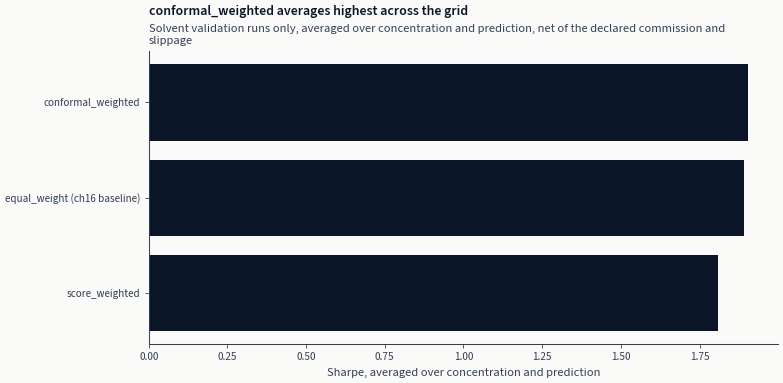

In [14]:
import matplotlib.pyplot as plt

# Only the allocators that have an average to draw. One whose runs all went insolvent
# carries a null here, and a bar of no length is indistinguishable from a bar of zero.
plottable = allocator_comparison.filter(pl.col("avg_sharpe").is_not_null())
unplotted = allocator_comparison.height - plottable.height
if unplotted:
    print(f"{unplotted} allocator(s) had no solvent run and are absent from the chart")

if not plottable.is_empty():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(
        plottable["allocator"].to_list(),
        plottable["avg_sharpe"].to_list(),
        color=COLORS["blue"],
    )
    # barh fills from the bottom, so without this the frame's descending order
    # arrives on the page ascending and the figure contradicts the table above it.
    ax.invert_yaxis()
    ax.set_xlabel("Sharpe, averaged over concentration and prediction")
    # Derived from the frame rather than asserted, so the title cannot outlive the
    # ordering it describes. The leader is the first row because the frame is sorted.
    leader = plottable["allocator"][0]
    add_message_title(
        ax,
        (
            f"{leader} averages highest across the grid"
            if leader != EQUAL_WEIGHT_LABEL
            else "Neither sizing rule averages above equal weighting across the grid"
        ),
        subtitle=(
            "Solvent validation runs only, averaged over concentration and prediction, "
            "net of the declared commission and slippage"
        ),
    )
    fig.tight_layout()
    show_with_alt(
        fig,
        "Horizontal bar chart of average validation Sharpe over the solvent runs, for "
        "each way of sizing the selected names, longest bar at the top. The bars are "
        "read against the table above it, which carries the same averages beside the "
        "count of runs that went insolvent and are therefore not in them.",
    )

### The upper tail of the allocation grid

The ten highest allocation-stage Sharpes among the solvent runs, with the
concentration and allocator behind each. Read it against the table above rather than
on its own: this is the tail of a grid, so the top row is the largest of eighty draws
and is inflated by that count. What is worth reading here is whether one allocator or
one concentration fills the tail, which would be a pattern, or whether the tail is
mixed, which would say the grid found no reliable ordering.

Insolvent runs are excluded here for the same reason they are excluded from the
averages, and the exclusion is a guard rather than a correction of this table. A path
that compounds through zero has its later gains and losses inverted, so its Sharpe is
arithmetic on a book that lost everything and can land anywhere, the top of the ranking
included. Whether any such row would have reached these ten depends on the run, and a
tail is where a single one would do the most damage, so the filter is applied whether
or not it removes anything. The grid is ranked first and filtered second, so ten rows
still appear wherever ten solvent runs exist.

In [15]:
top10 = (
    explorer.best(stage="allocation", top_n=9999, label=LABEL, prediction_hashes=ADVANCED_HASHES)
    .join(
        grid.filter(pl.col("stage") == "allocation").drop("stage"),
        on="backtest_hash",
        how="left",
    )
    .filter(SOLVENT)
    .head(10)
)
print(top10.select("source", "allocator", "names_per_side", "sharpe", "cagr", "max_drawdown"))

shape: (10, 6)
┌───────────────────┬────────────────────┬────────────────┬──────────┬──────────┬──────────────┐
│ source            ┆ allocator          ┆ names_per_side ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---               ┆ ---                ┆ ---            ┆ ---      ┆ ---      ┆ ---          │
│ str               ┆ str                ┆ i64            ┆ f64      ┆ f64      ┆ f64          │
╞═══════════════════╪════════════════════╪════════════════╪══════════╪══════════╪══════════════╡
│ gbm/leaves_63_mse ┆ conformal_weighted ┆ 50             ┆ 2.869934 ┆ 0.833028 ┆ -0.101036    │
│ gbm/leaves_7_mse  ┆ conformal_weighted ┆ 50             ┆ 2.735138 ┆ 1.055301 ┆ -0.14053     │
│ gbm/leaves_15_mse ┆ conformal_weighted ┆ 50             ┆ 2.474936 ┆ 0.899684 ┆ -0.112392    │
│ gbm/default_mse   ┆ conformal_weighted ┆ 50             ┆ 2.470415 ┆ 0.7759   ┆ -0.125454    │
│ gbm/leaves_31_mse ┆ conformal_weighted ┆ 50             ┆ 2.418336 ┆ 0.790507 ┆ -0.168112    │
│ gbm/leaves_7_

## What this notebook establishes, and what it does not

The sweep answers a narrow question: holding the prediction and the concentration
fixed, does sizing positions by the model's score or by a conformal interval earn
more than sizing them equally? The comparison is clean in the sense that every
allocator saw the same selected names at the same concentration.

It is not clean in a second sense, and that carries forward. The predictions that
entered were the ones that ranked highest at the equal-weight baseline, so this
stage inherits that selection and adds a grid of its own on top. Both counts feed
the trial count the strategy analysis notebook has to deflate by, and neither
number is visible in a Sharpe read off the table above.

Every Sharpe here is already net of the commission and slippage `setup.yaml`
declares, charged on turnover at each rebalance. What has not been tested is
whether that one cost assumption is the right one. That matters more at this stage
than at the last, because the allocators differ in how much they trade: a rule that
re-sizes every position each month turns over more than one that only changes which
names are held, so a cost assumption that is too low flatters the more active rule
specifically. A comparison run at a single cost level cannot show that.

**Next:** [`13_risk_management`](13_risk_management.ipynb), which tries leaving
positions early. The costs notebook runs after it, on the one configuration this case
study reports - selected across the baseline, this grid and the risk stage together -
and reads how fast that configuration's Sharpe decays as the charge rises.